In [33]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [34]:
df=pd.read_csv("DataCoSupplyChainDataset.csv",encoding='unicode_escape')
df

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Zipcode,Product Card Id,Product Category Id,Product Description,Product Image,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,2/3/2018 22:56,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/18/2018 12:27,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/17/2018 12:06,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/16/2018 11:45,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,NaN,1360,73,NaN,http://images.acmesports.sports/Smart+watch,Smart watch,327.750000,0,1/15/2018 11:24,Standard Class
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
180514,CASH,4,4,40.000000,399.980011,Shipping on time,0,45,Fishing,Brooklyn,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 3:40,Standard Class
180515,DEBIT,3,2,-613.770019,395.980011,Late delivery,1,45,Fishing,Bakersfield,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/19/2016 1:34,Second Class
180516,TRANSFER,5,4,141.110001,391.980011,Late delivery,1,45,Fishing,Bristol,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/20/2016 21:00,Standard Class
180517,PAYMENT,3,4,186.229996,387.980011,Advance shipping,0,45,Fishing,Caguas,...,NaN,1004,45,NaN,http://images.acmesports.sports/Field+%26+Stre...,Field & Stream Sportsman 16 Gun Fire Safe,399.980011,0,1/18/2016 20:18,Standard Class


### Exploratory Data Analysis(EDA)

In [35]:
print('rows,columns:',df.shape)
print('\n columns:',df.columns)
print('\n columns:',df.columns.to_list())
print('\n number of duplicates',df.duplicated().sum())
print('\n missing values:',df.isna().sum().sort_values(ascending=False).head(20))
print('\n columns:',df.columns.to_list())


rows,columns: (180519, 53)

 columns: Index(['Type', 'Days for shipping (real)', 'Days for shipment (scheduled)',
       'Benefit per order', 'Sales per customer', 'Delivery Status',
       'Late_delivery_risk', 'Category Id', 'Category Name', 'Customer City',
       'Customer Country', 'Customer Email', 'Customer Fname', 'Customer Id',
       'Customer Lname', 'Customer Password', 'Customer Segment',
       'Customer State', 'Customer Street', 'Customer Zipcode',
       'Department Id', 'Department Name', 'Latitude', 'Longitude', 'Market',
       'Order City', 'Order Country', 'Order Customer Id',
       'order date (DateOrders)', 'Order Id', 'Order Item Cardprod Id',
       'Order Item Discount', 'Order Item Discount Rate', 'Order Item Id',
       'Order Item Product Price', 'Order Item Profit Ratio',
       'Order Item Quantity', 'Sales', 'Order Item Total',
       'Order Profit Per Order', 'Order Region', 'Order State', 'Order Status',
       'Order Zipcode', 'Product Card Id', 'Pr

### In delivery time we dont want to the columns and remove and make the list

In [36]:
columns_drop=['Product Description',
             'Product Image',
             'Customer Email',
             'Customer Fname',
             'Customer Lname', 
             'Customer Password',
             'Customer Street',
             'Customer Zipcode',
             'Order Item Cardprod Id',
             'Order State',
             'Order Id',
              'Order Item Cardprod Id',
              'Order Item Discount', 
              'Order Item Discount Rate', 
              'Order Item Id', 
              'Order Item Product Price', 
              'Order Item Profit Ratio', 
              'Order Item Quantity', 
              'Sales', 
              'Order Item Total', 
              
              'Order Region',]

In [37]:
df=df.drop(columns=columns_drop)  #droping the columns

In [38]:
df=df[df['Delivery Status']!='Shipping canceled'] #remove cancel orders

In [39]:
for c in ['order date (DateOrders)','shipping date (DateOrders)']:
    df[c]=pd.to_datetime(df[c],dayfirst=False)

In [40]:
print(df[c])  #standrad dat converstion 
#shipping date means---exact date

0        2018-02-03 22:56:00
1        2018-01-18 12:27:00
2        2018-01-17 12:06:00
3        2018-01-16 11:45:00
4        2018-01-15 11:24:00
                 ...        
180514   2016-01-20 03:40:00
180515   2016-01-19 01:34:00
180516   2016-01-20 21:00:00
180517   2016-01-18 20:18:00
180518   2016-01-19 18:54:00
Name: shipping date (DateOrders), Length: 172765, dtype: datetime64[us]


In [41]:
#after data cleaning
print('rows,columns:',df.shape)
print('\nMissing values(top 5):')
print(df.isna().sum().sort_values(ascending=False).head(5))

rows,columns: (172765, 33)

Missing values(top 5):
Order Zipcode                    149045
Type                                  0
Days for shipping (real)              0
Benefit per order                     0
Days for shipment (scheduled)         0
dtype: int64


In [42]:
df.head() #top5 records

,Type,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Delivery Status,Late_delivery_risk,Category Id,Category Name,Customer City,...,Order Profit Per Order,Order Status,Order Zipcode,Product Card Id,Product Category Id,Product Name,Product Price,Product Status,shipping date (DateOrders),Shipping Mode
0,DEBIT,3,4,91.250000,314.640015,Advance shipping,0,73,Sporting Goods,Caguas,...,91.250000,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-02-03 22:56:00,Standard Class
1,TRANSFER,5,4,-249.089996,311.359985,Late delivery,1,73,Sporting Goods,Caguas,...,-249.089996,PENDING,NaN,1360,73,Smart watch,327.75,0,2018-01-18 12:27:00,Standard Class
2,CASH,4,4,-247.779999,309.720001,Shipping on time,0,73,Sporting Goods,San Jose,...,-247.779999,CLOSED,NaN,1360,73,Smart watch,327.75,0,2018-01-17 12:06:00,Standard Class
3,DEBIT,3,4,22.860001,304.809998,Advance shipping,0,73,Sporting Goods,Los Angeles,...,22.860001,COMPLETE,NaN,1360,73,Smart watch,327.75,0,2018-01-16 11:45:00,Standard Class
4,PAYMENT,2,4,134.210007,298.250000,Advance shipping,0,73,Sporting Goods,Caguas,...,134.210007,PENDING_PAYMENT,NaN,1360,73,Smart watch,327.75,0,2018-01-15 11:24:00,Standard Class


In [43]:
#value count for catogerical columns with low cardinalty
for col in df.columns:
    if df[col].nunique()<10:
        print(f'\n{col} value_counts :')
        print(df[col].value_counts())
        #days for shipment:the time it takes to process


Type value_counts :
Type
DEBIT       69295
TRANSFER    42129
PAYMENT     41725
CASH        19616
Name: count, dtype: int64

Days for shipping (real) value_counts :
Days for shipping (real)
2    54205
6    27489
3    27478
4    27297
5    27003
0     4839
1     4454
Name: count, dtype: int64

Days for shipment (scheduled) value_counts :
Days for shipment (scheduled)
4    103153
2     33806
1     26513
0      9293
Name: count, dtype: int64

Delivery Status value_counts :
Delivery Status
Late delivery       98977
Advance shipping    41592
Shipping on time    32196
Name: count, dtype: int64

Late_delivery_risk value_counts :
Late_delivery_risk
1    98977
0    73788
Name: count, dtype: int64

Customer Country value_counts :
Customer Country
EE. UU.        106425
Puerto Rico     66340
Name: count, dtype: int64

Customer Segment value_counts :
Customer Segment
Consumer       89420
Corporate      52528
Home Office    30817
Name: count, dtype: int64

Market value_counts :
Market
LATAM         

In [44]:
# calculating order processing time and delivery

df['Order Processing Time']=(df['shipping date (DateOrders)']-df['order date (DateOrders)']).dt.days

df['Delay']=df['Order Processing Time']=df['Days for shipment (scheduled)']

df['Is_Delayed']=df ['Delay']>0

df['order_month']=df['order date (DateOrders)'].dt.month

df['order_day']=df['order date (DateOrders)'].dt.day_name()

df['order_hour']=df['order date (DateOrders)'].dt.hour


df.describe()

,Days for shipping (real),Days for shipment (scheduled),Benefit per order,Sales per customer,Late_delivery_risk,Category Id,Customer Id,Department Id,Latitude,Longitude,...,Order Zipcode,Product Card Id,Product Category Id,Product Price,Product Status,shipping date (DateOrders),Order Processing Time,Delay,order_month,order_hour
count,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,172765.000000,...,23720.000000,172765.000000,172765.000000,172765.000000,172765.0,172765,172765.000000,172765.000000,172765.000000,172765.000000
mean,3.498596,2.933100,22.032360,183.165948,0.572900,31.856065,6687.759048,5.444095,29.724145,-84.912610,...,55333.729300,692.618858,31.856065,141.278595,0.0,2016-06-16 03:25:14.452927,2.933100,2.933100,6.235511,11.482604
min,0.000000,0.000000,-4274.979980,7.490000,0.000000,2.000000,1.000000,2.000000,-33.937553,-158.025986,...,1040.000000,19.000000,2.000000,9.990000,0.0,2015-01-03 00:00:00,0.000000,0.000000,1.000000,0.000000
25%,2.000000,2.000000,7.030000,104.379997,0.000000,18.000000,3252.000000,4.000000,18.265436,-98.443069,...,23434.000000,403.000000,18.000000,50.000000,0.0,2015-09-25 08:59:00,2.000000,2.000000,3.000000,5.000000
50%,3.000000,4.000000,31.520000,163.990005,1.000000,29.000000,6457.000000,5.000000,33.144863,-76.847908,...,57701.000000,627.000000,29.000000,59.990002,0.0,2016-06-15 03:38:00,4.000000,4.000000,6.000000,11.000000
75%,5.000000,4.000000,64.800003,247.399994,1.000000,45.000000,9782.000000,7.000000,39.279617,-66.370583,...,90004.000000,1004.000000,45.000000,199.990005,0.0,2017-03-04 08:00:00,4.000000,4.000000,9.000000,17.000000
max,6.000000,4.000000,911.799988,1939.989990,1.000000,76.000000,20757.000000,12.000000,48.781933,115.263077,...,99301.000000,1363.000000,76.000000,1999.989990,0.0,2018-02-06 22:14:00,4.000000,4.000000,12.000000,23.000000
std,1.623446,1.373405,104.355313,120.141871,0.494659,15.642216,4165.069180,1.629248,9.811816,21.410511,...,31908.368454,336.471170,15.642216,139.862956,0.0,NaN,1.373405,1.373405,3.405593,6.927276


In [45]:
#now count is_delay
df['Is_Delayed'].value_counts()

Is_Delayed
True     163472
False      9293
Name: count, dtype: int64

In [46]:
df['Order Profit Per Order'] #profit or lose

0          91.250000
1        -249.089996
2        -247.779999
3          22.860001
4         134.210007
             ...    
180514     40.000000
180515   -613.770019
180516    141.110001
180517    186.229996
180518    168.949997
Name: Order Profit Per Order, Length: 172765, dtype: float64

### now create categorical like profit,loss and break-event

In [47]:

df['Profitability Flag'] =np.where(df['Order Profit Per Order']>0, 'Profit', np.where(df['Order Profit Per Order']<0,'Loss', 'Break-Event')) 

df['Profitability Flag'].value_counts()

Profitability Flag
Profit         139354
Loss            32295
Break-Event      1116
Name: count, dtype: int64

In [48]:
#Percentage wise check the profit, Loss and Break-Event

df['Profitability Flag'].value_counts(normalize=True) # normalize -- decimals between 0 to 1

Profitability Flag
Profit         0.80661
Loss           0.18693
Break-Event    0.00646
Name: proportion, dtype: float64

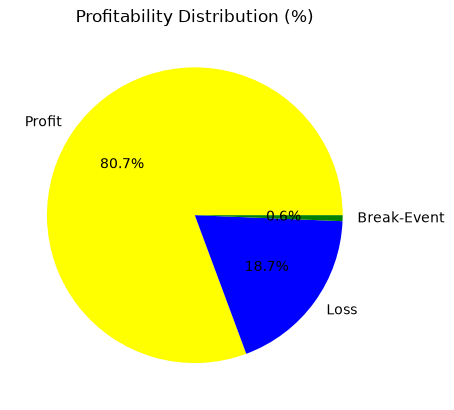

In [50]:
# Based on profit, Loss and Break-Event create pie chart

profit_counts=df ['Profitability Flag'].value_counts (normalize=True)*100

profit_counts.plot(kind='pie', autopct='%1.1f%%',colors=['yellow', 'blue', 'green'])

plt.ylabel('')

plt.title('Profitability Distribution (%)')

plt.savefig('catogerical like profit, loss and break-event.jpg')

plt.show()

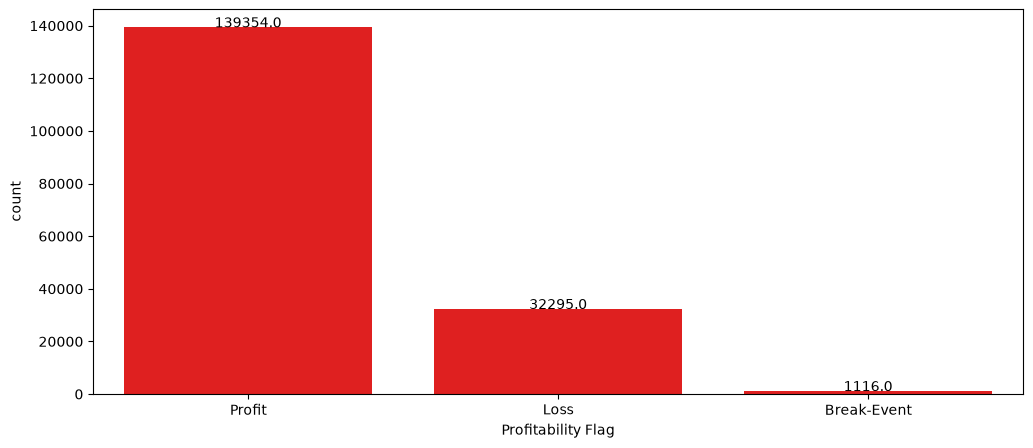

In [56]:
fig,ax=plt.subplots(nrows=1,ncols=1,figsize=(12,5))

sns.countplot(x='Profitability Flag', data=df,color='red')

for bar in ax.patches:

    yval=bar.get_height()

    ax.text(bar.get_x()+bar.get_width()/2.0,yval+20, yval, ha='center')